In [3]:

import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from General.segments import SEGMENT_INDEX
import colorsys
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
def build_label_colormap(max_label=128, background=(0,0,0)):
    colors = np.zeros((max_label + 1, 3), dtype=float)
    colors[0] = background
    golden_ratio = 0.61803398875
    h = 0.0
    for i in range(1, max_label + 1):
        h = (h + golden_ratio) % 1.0
        colors[i] = colorsys.hsv_to_rgb(h, 0.65, 0.95)
    return ListedColormap(colors)

MAX_LABEL = 128

# ✅ 只创建一次（全程复用）
cmap = build_label_colormap(MAX_LABEL, background=(0,0,0))

# ✅ 固定离散边界：每个整数label占一个bin
bounds = np.arange(-0.5, MAX_LABEL + 1.5, 1.0)  # -0.5, 0.5, 1.5, ... 128.5
norm = BoundaryNorm(bounds, cmap.N, clip=True)



FileNotFoundError: Missing files:
- warped_moving_pt: C:\Users\Sam\Downloads\viz\ctsmoothness_l6000_k10_mar3000_gam1\sample_0004\fdg_pt_warped.nii.gz
- warped_moving_mask: C:\Users\Sam\Downloads\viz\ctsmoothness_l6000_k10_mar3000_gam1\sample_0004\fdg_mask_warped.nii.gz
- fixed_pt: C:\Users\Sam\Downloads\viz\ctsmoothness_l6000_k10_mar3000_gam1\sample_0004\psma_pt.nii.gz
- fixed_mask: C:\Users\Sam\Downloads\viz\ctsmoothness_l6000_k10_mar3000_gam1\sample_0004\psma_ct_mask.nii.gz
- moving_mask: C:\Users\Sam\Downloads\viz\ctsmoothness_l6000_k10_mar3000_gam1\sample_0004\fdg_mask.nii.gz
- warped_moving_ct: C:\Users\Sam\Downloads\viz\ctsmoothness_l6000_k10_mar3000_gam1\sample_0004\fdg_ct_warped.nii.gz
- fixed_ct: C:\Users\Sam\Downloads\viz\ctsmoothness_l6000_k10_mar3000_gam1\sample_0004\psma_ct.nii.gz
- moving_ct: C:\Users\Sam\Downloads\viz\ctsmoothness_l6000_k10_mar3000_gam1\sample_0004\fdg_ct.nii.gz
- moving_pt: C:\Users\Sam\Downloads\viz\ctsmoothness_l6000_k10_mar3000_gam1\sample_0004\fdg_p

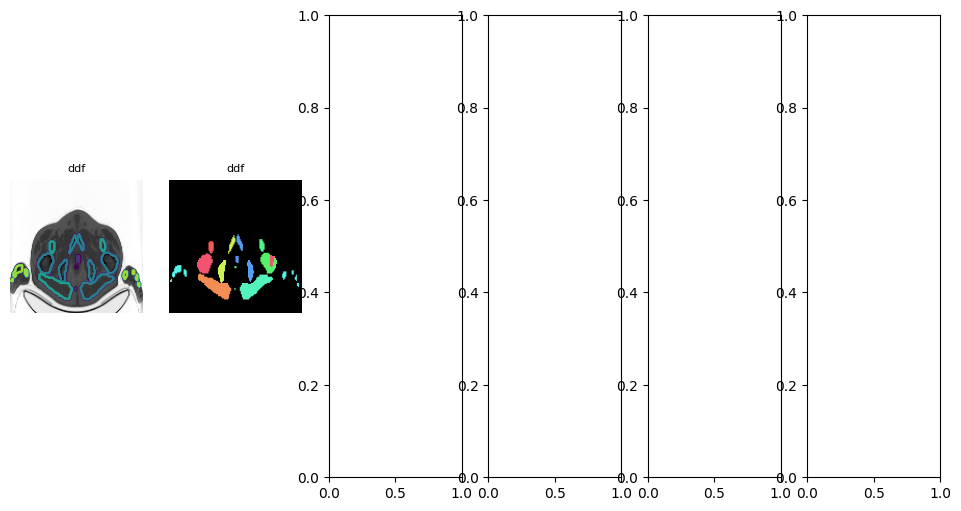

In [28]:


def return_file_path(base_dir: str, patient: str, image: str) -> str:
    """base_dir/<sample_patient>/<image>"""
    patient_dir = "sample_" + str(patient)
    return os.path.join(base_dir, patient_dir, image)


def load_patient_viz_slices(
    base_dir: str,
    hp_name: str,
    patient: str,
    slice_idx: int | None = None,
    slice_axis: int = 1,
    return_full_volumes: bool = False,
    return_sitk_images: bool = False,
):
    """
    Loads a set of NIfTI(.nii.gz) files for visualization and returns the selected 2D slices.

    Assumes data layout:
        base_dir/hp_name/sample_<patient>/<filename>.nii.gz

    Volumes are converted to NumPy arrays with shape (z, y, x) (SimpleITK convention via GetArrayFromImage).

    slice_axis:
        0 -> slice along z (gives (y,x))
        1 -> slice along y (gives (z,x))   [matches your original indexing [:, slice_idx, :]]
        2 -> slice along x (gives (z,y))

    Returns:
        dict with:
            - "paths": dict of file paths
            - "slices": dict of 2D numpy arrays
            - optionally "volumes": dict of 3D numpy arrays
            - optionally "sitk": dict of SimpleITK images
            - "slice_idx": used slice index
            - "slice_axis": used slice axis
    """
    root = os.path.join(base_dir, hp_name)

    # ---- paths ----
    paths = {
        "warped_moving_pt": return_file_path(root, patient, "fdg_pt_warped.nii.gz"),
        "warped_moving_mask": return_file_path(root, patient, "fdg_mask_warped.nii.gz"),
        "fixed_pt": return_file_path(root, patient, "psma_pt.nii.gz"),
        "fixed_mask": return_file_path(root, patient, "psma_ct_mask.nii.gz"),
        "moving_mask": return_file_path(root, patient, "fdg_mask.nii.gz"),
        "warped_moving_ct": return_file_path(root, patient, "fdg_ct_warped.nii.gz"),
        "fixed_ct": return_file_path(root, patient, "psma_ct.nii.gz"),
        "moving_ct": return_file_path(root, patient, "fdg_ct.nii.gz"),
        "moving_pt": return_file_path(root, patient, "fdg_pt.nii.gz"),
        "ddf": return_file_path(root, patient, "ddf.nii.gz"),
    }

    # sanity check (optional but helpful)
    missing = [k for k, p in paths.items() if not os.path.exists(p)]
    if missing:
        missing_str = "\n".join([f"- {k}: {paths[k]}" for k in missing])
        raise FileNotFoundError(f"Missing files:\n{missing_str}")

    # ---- read sitk ----
    sitk_imgs = {k: sitk.ReadImage(p) for k, p in paths.items()}

    # ---- to numpy ----
    vols = {k: sitk.GetArrayFromImage(img) for k, img in sitk_imgs.items()}

    # ---- choose slice ----
    if slice_idx is None:
        # default: middle slice along slice_axis
        slice_idx = fixed_vol.shape[slice_axis] // 2


    # print(vols["moving_mask"].shape, vols["ddf"].shape)
    slices = {
        "moving_mask_slice": vols["moving_mask"][slice_idx, ...],
        "moving_ct_slice": vols["moving_ct"][slice_idx, ...],
        "ddf_slice": vols["ddf"][:, :, slice_idx, :],
    }

    out = {
        "paths": paths,
        "slices": slices,
        "slice_idx": slice_idx,
        "slice_axis": slice_axis,
    }

    if return_full_volumes:
        out["volumes"] = vols
    if return_sitk_images:
        out["sitk"] = sitk_imgs

    return out

def ddf_rgb_clip_rescale(ddf, clip=0.2, component_order=(0, 1, 2)):
    """
    ddf: (H,W,3)
    clip: float -> clip to [-clip, clip]
    component_order: map channels to (R,G,B). Default assumes ch0,ch1,ch2.
    """
    ddf = np.asarray(ddf, dtype=np.float32)
    if ddf.ndim != 3 or ddf.shape[-1] != 3:
        raise ValueError(f"Expected (H,W,3), got {ddf.shape}")

    ddf = ddf[..., list(component_order)]          # reorder if needed
    ddf = np.clip(ddf, -clip, clip)               # clip to [-clip, clip]
    rgb = (ddf + clip) / (2.0 * clip)             # rescale to [0,1]
    return np.clip(rgb, 0.0, 1.0)



sidx = 200
bl = '6000'
data = load_patient_viz_slices(
    base_dir=r"C:\Users\Sam\Downloads\viz",
    hp_name=fr"ctsmoothness_l{bl}_k10_mar3000_gam2.0",
    patient="0004",
    slice_idx=sidx,      # or None for middle
    slice_axis=1,      # axis=1 gives [:, slice_idx, :]
    return_full_volumes=False,
)
moving_mask_slice = data["slices"]["moving_mask_slice"]
moving_pt_slice = data["slices"]["moving_ct_slice"]
ddf_slice = data["slices"]["ddf_slice"]

fig, axes = plt.subplots(1, 6, figsize=(12, 6))  # 1 row, 6 columns


# Column 7: Warped Moving CT Mask (overlay)
axes[0].imshow(np.rot90(moving_pt_slice, k=0), cmap='gray_r')
axes[0].contour(np.rot90(moving_mask_slice, k=0))
axes[0].set_title("ddf", fontsize=8)
axes[0].axis("off")

axes[1].imshow(np.rot90(moving_mask_slice, k=0), cmap=cmap)
axes[1].set_title("ddf", fontsize=8)
axes[1].axis("off")

for idx, name in enumerate([1, 2]):
    data = load_patient_viz_slices(
        base_dir=r"C:\Users\Sam\Downloads\viz",
        hp_name=fr"ctsmoothness_l{bl}_k10_mar3000_gam{str(name)}",
        patient="0004",
        slice_idx=sidx,      # or None for middle
        slice_axis=1,      # axis=1 gives [:, slice_idx, :]
        return_full_volumes=False,
    )
    moving_mask_slice = data["slices"]["moving_mask_slice"]
    moving_pt_slice = data["slices"]["moving_ct_slice"]
    ddf_slice = data["slices"]["ddf_slice"]


    ddf_slice = ddf_rgb_clip_rescale(ddf_slice, clip=0.1, component_order=(1, 0, 2))




    axes[idx+2].imshow(np.rot90(ddf_slice, k=3))
    axes[idx+2].set_title("ddf", fontsize=8)
    axes[idx+2].axis("off")
plt.tight_layout()
plt.show()